# Part 1: Generate Circuits

Install packages

In [ ]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=28abeecec96301978101e84f892fc9b582a4b22bd71fa5afaacbbd426a3d3577
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [77]:
!pip install qiskit[visualization] qiskit-aer qiskit-ibm-runtime

In [ ]:
!pip install matplotlib pylatexenc

In [51]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector, plot_state_city, plot_state_hinton
from qiskit.quantum_info import Statevector, SparsePauliOp

Single qubit gate circuits:

In [ ]:
qr=QuantumRegister(1)
cr=ClassicalRegister(1)
qc=QuantumCircuit(qr, cr)
qc.h(qr[0])
qc.x(qr[0])
qc.s(qr[0])
qc1 = qc.copy()
# qc1.measure_all()
qc1.measure(qr, cr)

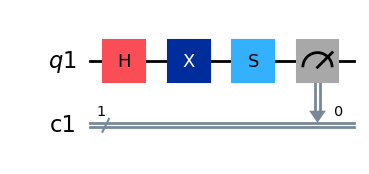

In [ ]:
qc1.draw(output="mpl")

In [79]:
qc1.draw(output="text")

┌───┐┌───┐┌───┐┌─┐
  q1: ┤ H ├┤ X ├┤ S ├┤M├
      └───┘└───┘└───┘└╥┘
c1: 1/════════════════╩═
                      0

In [ ]:
sim=AerSimulator()
job=sim.run(qc1)
result=job.result()
output=result.get_counts()
print(output)

{'0': 511, '1': 513}


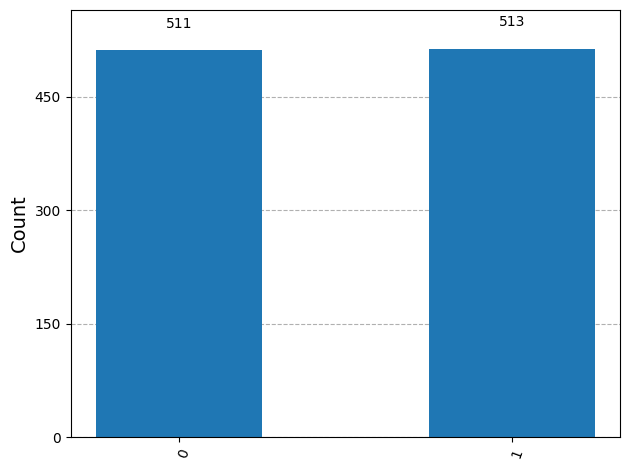

In [80]:
plot_histogram(output)

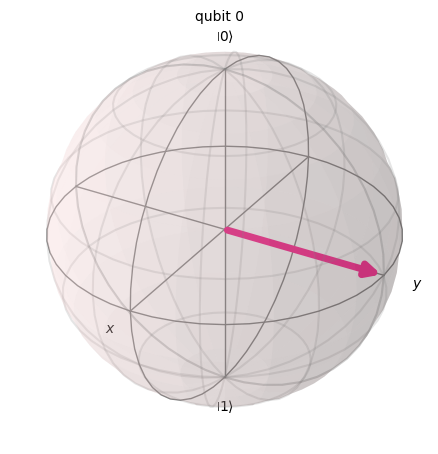

In [81]:
# Get the statevector and plot it on the Bloch Sphere
state=Statevector.from_instruction(qc)
state.draw("bloch")

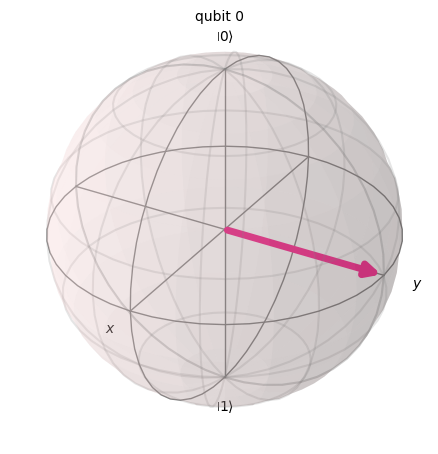

In [31]:
plot_bloch_multivector(state)

Bell Circuit (Circuit with 2 qubit gates)

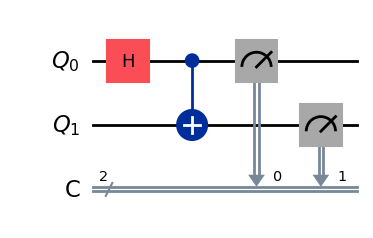

In [34]:
qreg=QuantumRegister(2,'Q')
creg=ClassicalRegister(2,'C')
bell_circ=QuantumCircuit(qreg,creg)

bell_circ.h(qreg[0])
bell_circ.cx(qreg[0],qreg[1])   #qr[0]-control, qr[1]-target
# bell_circ.measure_all()
bell_circ1= bell_circ.copy()
#bell_circ1.measure(qreg[0], creg[0])
#bell_circ1.measure(qreg[1], creg[1])
bell_circ1.measure([qreg[0],qreg[1]], [creg[0],creg[1]])
bell_circ1.draw(output='mpl')

In [35]:
sim=AerSimulator()
job_b=sim.run(bell_circ1)
result_b=job_b.result()
output_b=result_b.get_counts()
print(output_b)

{'00': 508, '11': 516}


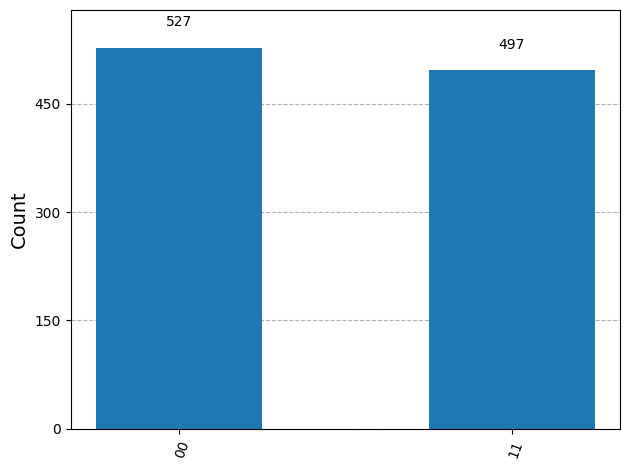

In [ ]:
plot_histogram(output_b)

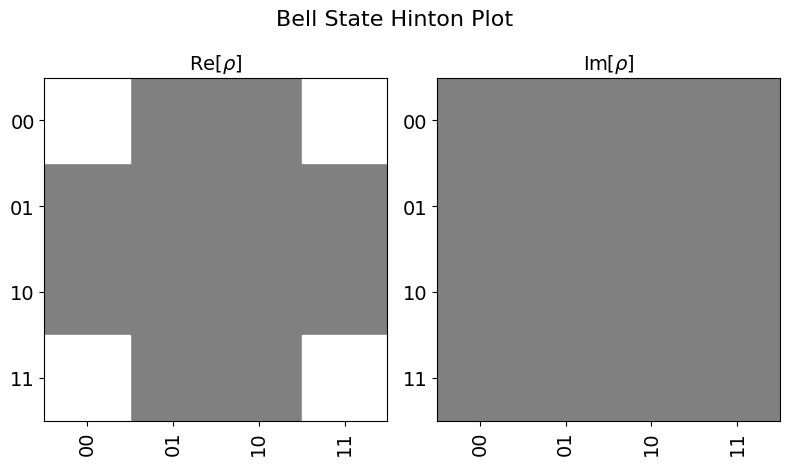

In [40]:
state_1 = Statevector.from_instruction(bell_circ)

# Plot a 2D "Hinton" diagram where box size equals magnitude
plot_state_hinton(state_1, title="Bell State Hinton Plot")

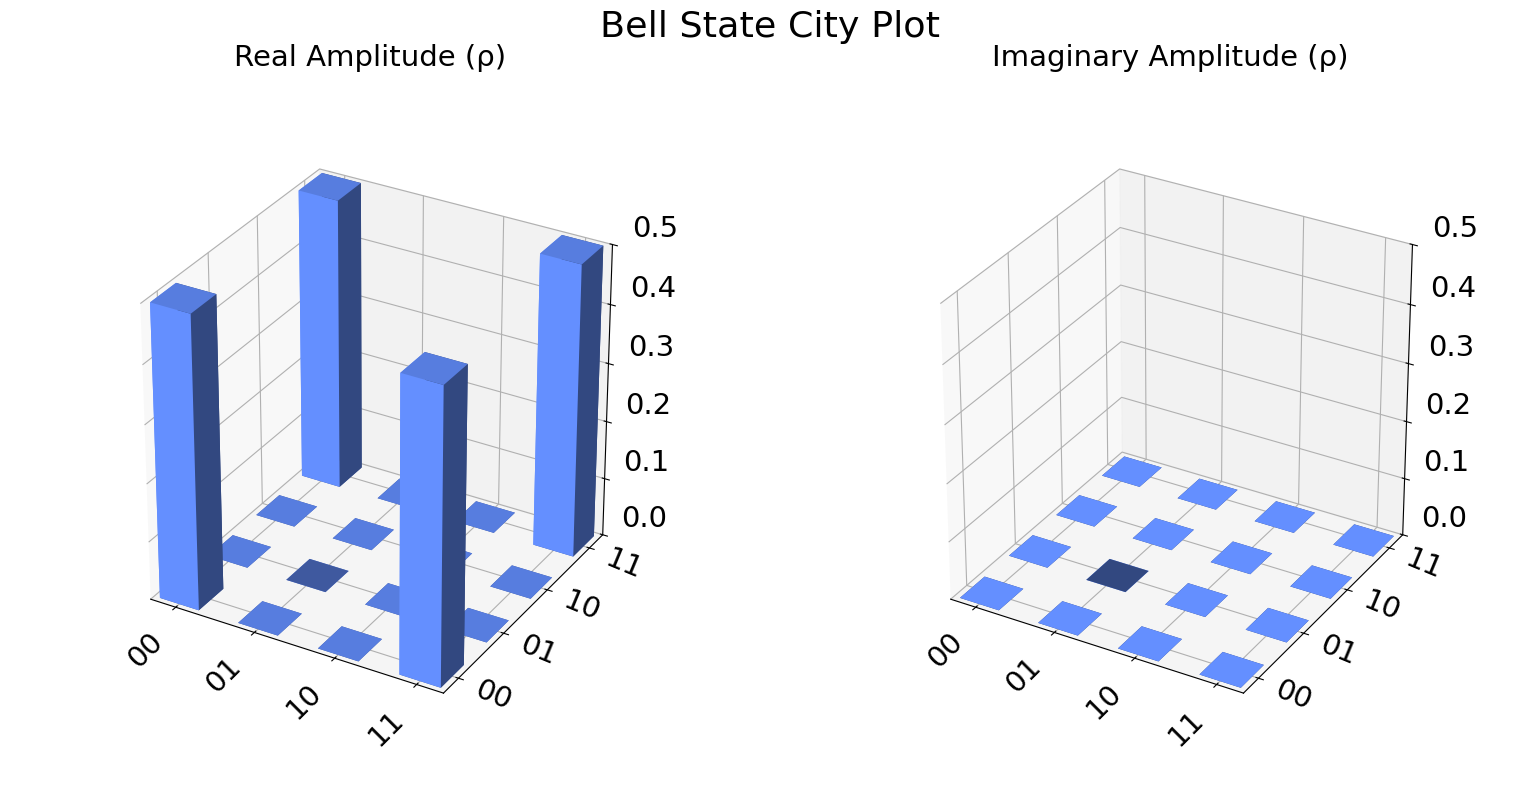

In [41]:
# Plot a 3D "City" visualization of real and imaginary parts
plot_state_city(state_1, title="Bell State City Plot")

GHZ circuit (3-qubit entanglement circuit)

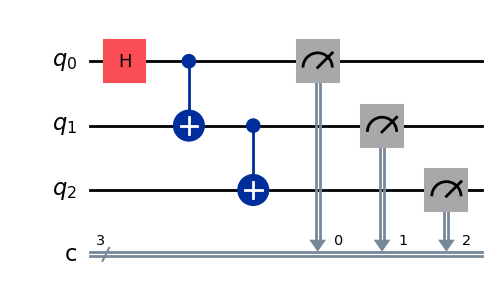

In [ ]:
qr_ghz=QuantumRegister(3, 'q')
cr_ghz=ClassicalRegister(3, 'c')
qc_ghz=QuantumCircuit(qr_ghz,cr_ghz)

qc_ghz.h(qr_ghz[0])
qc_ghz.cx(qr_ghz[0],qr_ghz[1])
qc_ghz.cx(qr_ghz[1], qr_ghz[2])
qc_ghz.measure(qr_ghz[0], cr_ghz[0])
qc_ghz.measure(qr_ghz[1], cr_ghz[1])
qc_ghz.measure(qr_ghz[2], cr_ghz[2])
qc_ghz.draw('mpl')

In [78]:
job_ghz=AerSimulator().run(qc_ghz)
result_ghz=job_ghz.result()
output_2=result_ghz.get_counts()
print(output_2)

{'111': 513, '000': 511}


# Part 2: Various execution methods

# Qiskit Simulation and Hardware Execution Architecture

After designing quantum circuits or algorithms, they can be executed either on simulators running on classical hardware (CPU/GPU environments) or on actual quantum hardware

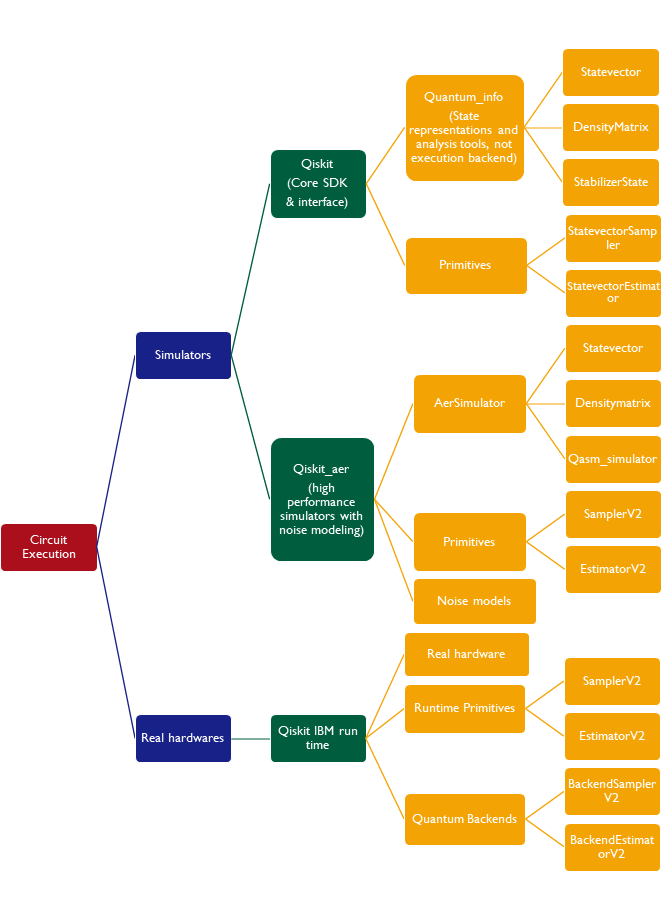

In [44]:
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

StatevectorSampler

In [45]:
sampler = StatevectorSampler()

In [47]:
""" list is a PUB (primitive unified Bloc), which consists of quantum circuits, parameters and number of shots """
job_samp = sampler.run([qc1], shots = 1024)


In [49]:
result_samp = job_samp.result()
result_samp

PrimitiveResult([SamplerPubResult(data=DataBin(c1=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})

In [50]:
counts_samp = result_samp[0].data.c1.get_counts()
counts_samp

{'0': 506, '1': 518}

StatevectorEstimator

In [53]:
Observable= [SparsePauliOp(["X"], [0.1])]
estimator = StatevectorEstimator()
result_estimator= estimator.run([(qc, Observable)], precision=0.1).result()
expectation_value= result_estimator[0].data.evs
print(expectation_value)

[0.0229364]


qiskit_aer

In [55]:
from qiskit_aer import QasmSimulator


In [57]:
simulator = AerSimulator(method ="statevector")

In [59]:
from qiskit_aer.primitives import SamplerV2, EstimatorV2

qiskit ibm runtime (for real-hardware)

In [58]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [74]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="LFsogztwnQVatNMK70c2hV_PMd7h_2-5vYl8zvCBI24p", overwrite=True
)

In [75]:
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-05-25 04:48:58,795: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [72]:
print("Successfully connected! Available backends:")
print(service.backends())

qiskit_runtime_service.backends:WARNING:2026-05-25 04:48:38,547: Loading instance: open-instance, plan: open


Successfully connected! Available backends:
[<IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_fez')>]


In [76]:
backend = service.least_busy(operational = True, simulator = False)
print(backend.name)

qiskit_runtime_service.backends:WARNING:2026-05-25 04:53:33,491: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-25 04:53:36,303: Using instance: open-instance, plan: open


ibm_kingston
